## Step-1: Import Libraries

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 55)
print("   IRIS FLOWER CLASSIFICATION — ML PROJECT")
print("=" * 55)

   IRIS FLOWER CLASSIFICATION — ML PROJECT


## # STEP 2: Load and explore the dataset

In [38]:
print("\n📦 STEP 2: Loading the Iris dataset...")

iris = load_iris()
X = iris.data          # Shape: (150, 4) — the 4 measurements
y = iris.target        # Shape: (150,)   — species labels: 0, 1, 2

print(f"   Dataset shape     : {X.shape}")
print(f"   Feature names     : {iris.feature_names}")
print(f"   Target names      : {list(iris.target_names)}")
print(f"   Class distribution: {dict(zip(iris.target_names, np.bincount(y)))}")
print(f"\n   First 5 samples:")
print(f"   {'Sepal L':>8} {'Sepal W':>8} {'Petal L':>8} {'Petal W':>8} {'Species':>12}")
print(f"   {'-'*52}")


📦 STEP 2: Loading the Iris dataset...
   Dataset shape     : (150, 4)
   Feature names     : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
   Target names      : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
   Class distribution: {np.str_('setosa'): np.int64(50), np.str_('versicolor'): np.int64(50), np.str_('virginica'): np.int64(50)}

   First 5 samples:
    Sepal L  Sepal W  Petal L  Petal W      Species
   ----------------------------------------------------


## STEP 3: Split into train and test sets


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing = 30 samples
    random_state=42,    # Seed for reproducibility
    stratify=y          # Keep class balance in both splits
)

print(f"   Training samples  : {len(X_train)}")
print(f"   Testing samples   : {len(X_test)}")
print(f"   Train class dist  : {np.bincount(y_train)}")
print(f"   Test class dist   : {np.bincount(y_test)}")

   Training samples  : 120
   Testing samples   : 30
   Train class dist  : [40 40 40]
   Test class dist   : [10 10 10]


## # STEP 4: Feature scaling (StandardScaler)

In [32]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # Fit ON train, transform train
X_test_s  = scaler.transform(X_test)        # Transform test using train stats

print(f"   Before scaling — mean of feature 0: {X_train[:,0].mean():.2f}")
print(f"   After  scaling — mean of feature 0: {X_train_s[:,0].mean():.4f} (≈ 0)")
print(f"   Before scaling — std  of feature 0: {X_train[:,0].std():.2f}")
print(f"   After  scaling — std  of feature 0: {X_train_s[:,0].std():.4f} (≈ 1)")

   Before scaling — mean of feature 0: 5.84
   After  scaling — mean of feature 0: -0.0000 (≈ 0)
   Before scaling — std  of feature 0: 0.84
   After  scaling — std  of feature 0: 1.0000 (≈ 1)


## STEP 5: Train Model A — K-Nearest Neighbors

In [33]:
dt = DecisionTreeClassifier(
    max_depth=3,         # Limit depth to avoid overfitting
    random_state=42
)
dt.fit(X_train_s, y_train)
y_pred_dt = dt.predict(X_test_s)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"   Decision Tree Accuracy: {acc_dt:.2%}")

   Decision Tree Accuracy: 96.67%


## # STEP 5b: Train Model B — Decision Tree

In [34]:
knn = KNeighborsClassifier(
    n_neighbors=5,       # Consider 5 closest training points
    metric='euclidean'   # Straight-line distance in feature space
)
knn.fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"   KNN Accuracy: {acc_knn:.2%}")

   KNN Accuracy: 93.33%


## # STEP 6: Cross-validation (more robust estimate)

In [35]:
print("\n🔁 STEP 6: 5-Fold Cross-Validation...")

cv_knn = cross_val_score(knn, scaler.fit_transform(X), y, cv=5)
cv_dt  = cross_val_score(dt,  scaler.fit_transform(X), y, cv=5)

print(f"   KNN  CV scores : {[f'{s:.2%}' for s in cv_knn]}")
print(f"   KNN  CV mean   : {cv_knn.mean():.2%} ± {cv_knn.std():.2%}")
print(f"   DT   CV scores : {[f'{s:.2%}' for s in cv_dt]}")
print(f"   DT   CV mean   : {cv_dt.mean():.2%} ± {cv_dt.std():.2%}")


🔁 STEP 6: 5-Fold Cross-Validation...
   KNN  CV scores : ['96.67%', '96.67%', '93.33%', '93.33%', '100.00%']
   KNN  CV mean   : 96.00% ± 2.49%
   DT   CV scores : ['96.67%', '96.67%', '93.33%', '100.00%', '100.00%']
   DT   CV mean   : 97.33% ± 2.49%


## # STEP 7: Full evaluation — classification report

In [36]:
print("\n📊 STEP 7: Classification Report — KNN")
print("-" * 55)
print(classification_report(
    y_test, y_pred_knn,
    target_names=iris.target_names
))

print("📊 Classification Report — Decision Tree")
print("-" * 55)
print(classification_report(
    y_test, y_pred_dt,
    target_names=iris.target_names
))


📊 STEP 7: Classification Report — KNN
-------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

📊 Classification Report — Decision Tree
-------------------------------------------------------
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## STEP 8: Predict on new, custom samples


In [37]:
print("\n🌸 STEP 8: Predicting custom flower measurements...")

new_flowers = np.array([
    [5.0, 3.5, 1.4, 0.2],   # Expected: Setosa
    [6.0, 2.8, 4.5, 1.4],   # Expected: Versicolor
    [6.7, 3.0, 5.6, 2.3],   # Expected: Virginica
])

new_flowers_scaled = scaler.transform(new_flowers)
predictions = knn.predict(new_flowers_scaled)
probabilities = knn.predict_proba(new_flowers_scaled)

print(f"\n   {'Sample':<8} {'Sepal L':>8} {'Sepal W':>8} {'Petal L':>8} {'Petal W':>8}  {'Predicted':>12}  {'Confidence':>10}")
print(f"   {'-'*72}")
for i, (flower, pred, prob) in enumerate(zip(new_flowers, predictions, probabilities)):
    species = iris.target_names[pred]
    confidence = prob.max()
    print(f"   #{i+1:<6} {flower[0]:>8.1f} {flower[1]:>8.1f} {flower[2]:>8.1f} {flower[3]:>8.1f}  {species:>12}  {confidence:>9.0%}")



🌸 STEP 8: Predicting custom flower measurements...

   Sample    Sepal L  Sepal W  Petal L  Petal W     Predicted  Confidence
   ------------------------------------------------------------------------
   #1           5.0      3.5      1.4      0.2        setosa       100%
   #2           6.0      2.8      4.5      1.4    versicolor       100%
   #3           6.7      3.0      5.6      2.3     virginica       100%


## STEP 9: Visualizations (5 plots


📈 STEP 9: Generating visualizations...


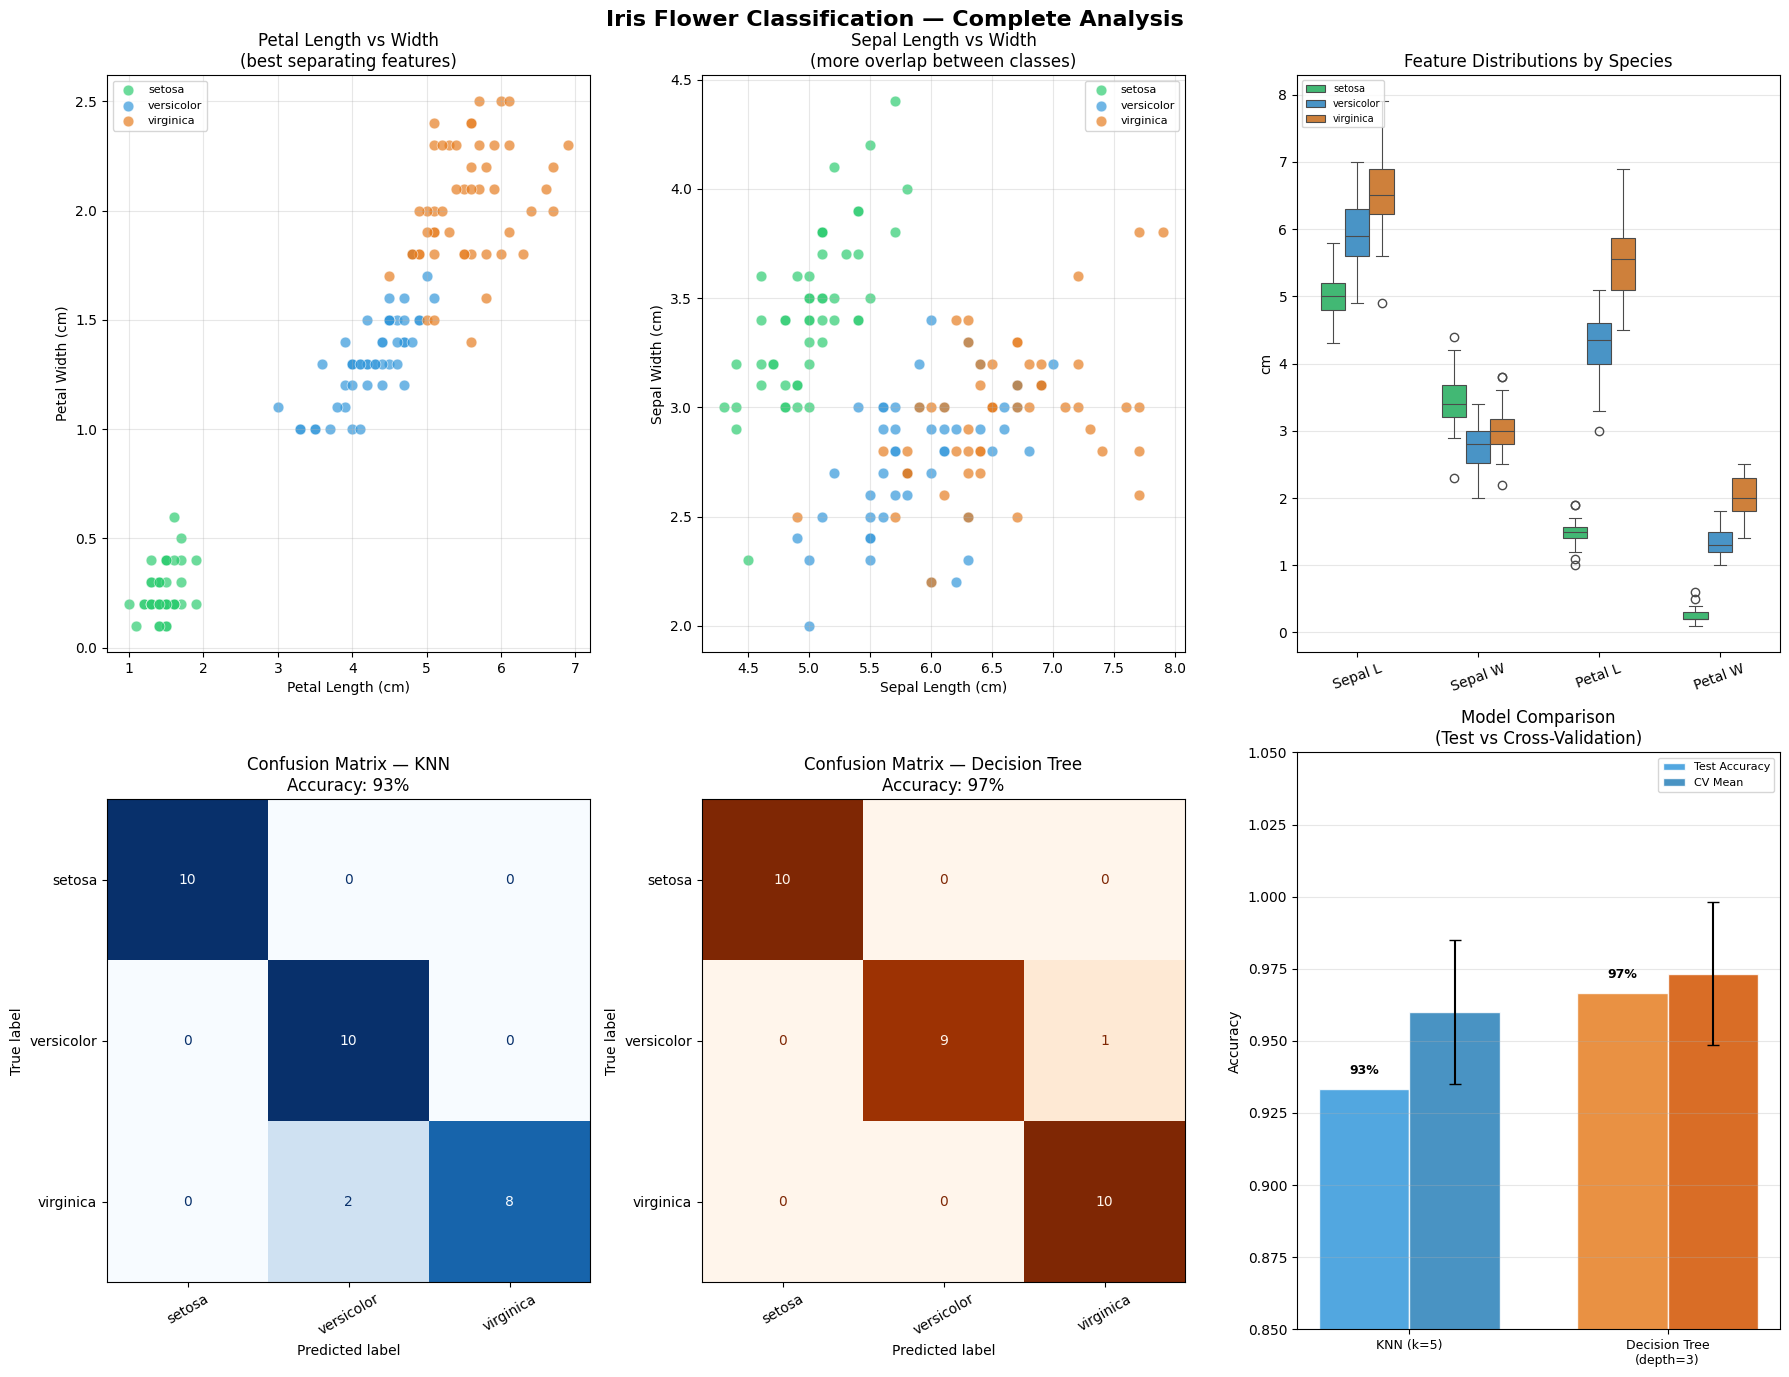

   Plots saved to iris_results.png


In [20]:
print("\n📈 STEP 9: Generating visualizations...")

colors = ['#2ecc71', '#3498db', '#e67e22']   # Setosa=green, Versicolor=blue, Virginica=orange
species_labels = list(iris.target_names)

fig = plt.figure(figsize=(18, 14))
fig.suptitle("Iris Flower Classification — Complete Analysis", fontsize=16, fontweight='bold', y=0.98)

# ── Plot 1: Feature scatter (Petal Length vs Petal Width) ──────────────────
ax1 = fig.add_subplot(2, 3, 1)
for cls in range(3):
    mask = y == cls
    ax1.scatter(X[mask, 2], X[mask, 3],
                c=colors[cls], label=species_labels[cls],
                alpha=0.7, edgecolors='white', linewidths=0.5, s=60)
ax1.set_xlabel("Petal Length (cm)")
ax1.set_ylabel("Petal Width (cm)")
ax1.set_title("Petal Length vs Width\n(best separating features)")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Feature scatter (Sepal Length vs Sepal Width) ─────────────────
ax2 = fig.add_subplot(2, 3, 2)
for cls in range(3):
    mask = y == cls
    ax2.scatter(X[mask, 0], X[mask, 1],
                c=colors[cls], label=species_labels[cls],
                alpha=0.7, edgecolors='white', linewidths=0.5, s=60)
ax2.set_xlabel("Sepal Length (cm)")
ax2.set_ylabel("Sepal Width (cm)")
ax2.set_title("Sepal Length vs Width\n(more overlap between classes)")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── Plot 3: Feature distributions (box plots) ─────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)
import pandas as pd
df = pd.DataFrame(X, columns=['Sepal L', 'Sepal W', 'Petal L', 'Petal W'])
df['Species'] = [species_labels[i] for i in y]
df_melt = df.melt(id_vars='Species', var_name='Feature', value_name='cm')
palette = {'setosa': colors[0], 'versicolor': colors[1], 'virginica': colors[2]}
sns.boxplot(data=df_melt, x='Feature', y='cm', hue='Species',
            palette=palette, ax=ax3, width=0.6, linewidth=0.8)
ax3.set_title("Feature Distributions by Species")
ax3.set_xlabel("")
ax3.tick_params(axis='x', rotation=20)
ax3.legend(fontsize=7, loc='upper left')
ax3.grid(True, alpha=0.3, axis='y')

# ── Plot 4: Confusion matrix — KNN ────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=iris.target_names)
disp.plot(ax=ax4, colorbar=False, cmap='Blues')
ax4.set_title(f"Confusion Matrix — KNN\nAccuracy: {acc_knn:.0%}")
ax4.tick_params(axis='x', rotation=30)

# ── Plot 5: Confusion matrix — Decision Tree ──────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=iris.target_names)
disp2.plot(ax=ax5, colorbar=False, cmap='Oranges')
ax5.set_title(f"Confusion Matrix — Decision Tree\nAccuracy: {acc_dt:.0%}")
ax5.tick_params(axis='x', rotation=30)

# ── Plot 6: Model comparison bar chart ────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)
models = ['KNN (k=5)', 'Decision Tree\n(depth=3)']
test_accs = [acc_knn, acc_dt]
cv_means = [cv_knn.mean(), cv_dt.mean()]
cv_stds  = [cv_knn.std(), cv_dt.std()]
x = np.arange(len(models))
width = 0.35
bars1 = ax6.bar(x - width/2, test_accs, width, label='Test Accuracy',
                color=['#3498db', '#e67e22'], alpha=0.85, edgecolor='white')
bars2 = ax6.bar(x + width/2, cv_means, width, label='CV Mean',
                color=['#2980b9', '#d35400'], alpha=0.85, edgecolor='white',
                yerr=cv_stds, capsize=4)
ax6.set_ylim(0.85, 1.05)
ax6.set_ylabel("Accuracy")
ax6.set_title("Model Comparison\n(Test vs Cross-Validation)")
ax6.set_xticks(x)
ax6.set_xticklabels(models, fontsize=9)
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
             f'{bar.get_height():.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("iris_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("   Plots saved to iris_results.png")

##  STEP 10: Decision Tree visualization



🌳 STEP 10: Visualizing the Decision Tree rules...


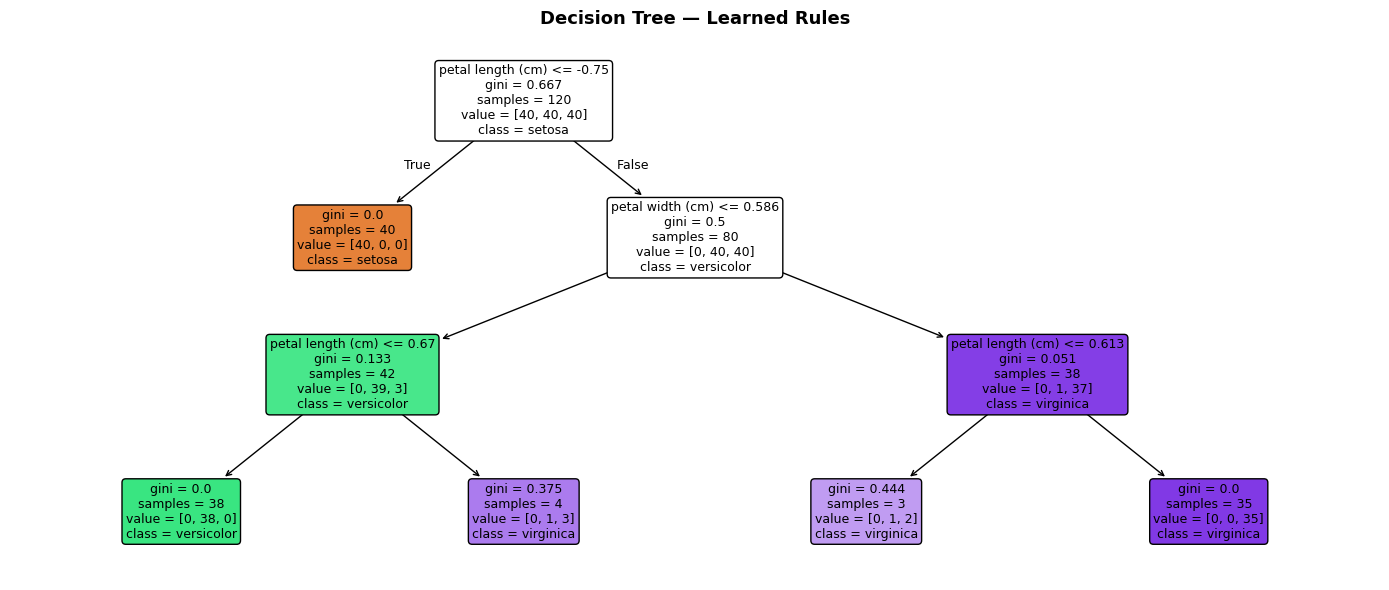

   Tree saved to iris_decision_tree.png


In [28]:
print("\n🌳 STEP 10: Visualizing the Decision Tree rules...")

fig2, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title("Decision Tree — Learned Rules", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("iris_decision_tree.png", dpi=150, bbox_inches='tight')
plt.show()
print("   Tree saved to iris_decision_tree.png")